In [1]:
import copy
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import wandb

from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDIMScheduler, DDPMScheduler
from monai.transforms import Compose, EnsureType, RandAffine, RandFlip, ScaleIntensity

# ── auto-locate brain_only directory ────────────────────────────────────
def _find_data_root(dirname='brain_only'):
    # 1. check cwd and every parent (works locally regardless of drive/path)
    for p in [Path.cwd(), *Path.cwd().parents]:
        candidate = p / dirname
        if candidate.is_dir():
            return candidate
    # 2. common RunPod / cloud paths
    for p in [Path('/workspace/brats'), Path('/workspace'), Path.home()]:
        candidate = p / dirname
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find '{dirname}' directory. "
        f"Place the data folder next to this notebook or set DATA_ROOT manually."
    )

DATA_ROOT  = _find_data_root()
LOG_DIR    = Path.cwd() / 'logs'
CKPT_DIR   = LOG_DIR / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)
(LOG_DIR / 'figures').mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DATA_ROOT: {DATA_ROOT}')
print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')

DATA_ROOT: /workspace/Brats/brain_only
Device   : cuda
PyTorch  : 2.8.0+cu128


In [2]:
import os
import hashlib

# ── subject discovery ───────────────────────────────────────────────────
def discover_thin_subjects(root, threshold_mm=2.0):
    subjects = []
    for child in sorted(root.iterdir()):
        nii = child / 't1_brain.nii.gz'
        if not (child.is_dir() and nii.exists()):
            continue
        img  = nib.load(str(nii))
        z_sp = float(np.sqrt((img.affine[:3, 2] ** 2).sum()))
        if z_sp < threshold_mm:
            subjects.append(dict(
                id=child.name, path=nii,
                z_sp=round(z_sp, 3),
                shape=tuple(img.header.get_data_shape()[:3]),
            ))
    return subjects


def split_subjects(subjects, train_frac=0.80, val_frac=0.10, seed=42):
    rng    = random.Random(seed)
    names  = sorted(s['id'] for s in subjects)
    rng.shuffle(names)
    lookup = {s['id']: s for s in subjects}
    ordered = [lookup[n] for n in names]
    n        = len(ordered)
    n_train  = int(n * train_frac)
    n_val    = int(n * val_frac)
    return ordered[:n_train], ordered[n_train:n_train+n_val], ordered[n_train+n_val:]


# ── slice preprocessing ──────────────────────────────────────────────────
def preprocess_volume(nii_path, target_size=256, z_low=0.15, z_high=0.85, fill_thresh=0.05):
    vol = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
    if vol.ndim != 3:
        return []
    nonzero = vol[vol != 0]
    if nonzero.size == 0:
        return []
    p_lo, p_hi = np.percentile(nonzero, [0.5, 99.5])
    vol = np.clip((vol - p_lo) / max(float(p_hi - p_lo), 1e-6), 0.0, 1.0)
    D   = vol.shape[2]
    z0, z1 = int(np.floor(D * z_low)), int(min(np.ceil(D * z_high), D))
    slices = []
    for zi in range(z0, z1):
        s = vol[:, :, zi]
        if np.count_nonzero(s) / s.size < fill_thresh:
            continue
        if s.shape[0] != target_size or s.shape[1] != target_size:
            t = torch.from_numpy(s[None, None])
            s = F.interpolate(t, (target_size, target_size),
                              mode='bilinear', align_corners=False).squeeze().numpy()
        slices.append(s[np.newaxis].astype(np.float32))   # numpy, not tensor
    return slices


# ── disk cache ───────────────────────────────────────────────────────────
CACHE_DIR = Path('/workspace/slice_cache')   # change if needed

def build_disk_cache(subjects, cache_dir=CACHE_DIR, target_size=256):
    """
    Preprocess all subjects and save each slice as an .npy file.
    Also writes a slice_index.csv mapping (npy_path) for fast reloading.
    Skips subjects that are already cached.
    """
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    index_path = cache_dir / 'slice_index.csv'

    # load existing index if present
    if index_path.exists():
        existing = set(open(index_path).read().splitlines())
    else:
        existing = set()

    new_rows = []
    for entry in subjects:
        subj_dir = cache_dir / entry['id']
        subj_dir.mkdir(exist_ok=True)

        slices = preprocess_volume(entry['path'], target_size=target_size)
        for sl_idx, arr in enumerate(slices):
            fname = subj_dir / f'slice_{sl_idx:04d}.npy'
            row   = str(fname)
            if row not in existing:
                np.save(str(fname), arr)
                new_rows.append(row)

    # append new rows to index
    with open(index_path, 'a') as f:
        for row in new_rows:
            f.write(row + '\n')

    print(f"Cache: {len(new_rows)} new slices written to {cache_dir}")
    return index_path


def load_index(index_path):
    """Load slice paths from index file."""
    with open(index_path) as f:
        paths = [Path(l.strip()) for l in f if l.strip()]
    return paths


# ── dataset ──────────────────────────────────────────────────────────────
class ThinSliceDataset(Dataset):
    """
    Reads preprocessed .npy slices from disk.
    No in-memory caching — each slice is loaded on demand.
    """
    def __init__(self, slice_paths, transform=None):
        self.slice_paths = slice_paths
        self.transform   = transform
        print(f"Dataset: {len(self.slice_paths)} slices")

    def __len__(self):
        return len(self.slice_paths)

    def __getitem__(self, idx):
        arr    = np.load(str(self.slice_paths[idx]))          # (1, 256, 256) float32
        tensor = torch.from_numpy(arr.copy())
        if self.transform:
            tensor = self.transform(tensor)
        return tensor


# ── build splits & loaders ───────────────────────────────────────────────
all_thin                         = discover_thin_subjects(DATA_ROOT)
train_subjects, val_subjects, _  = split_subjects(all_thin)

# verify no overlap
train_ids = {s['id'] for s in train_subjects}
val_ids   = {s['id'] for s in val_subjects}
assert len(train_ids & val_ids) == 0, "Subject leakage!"

# build disk cache (skips already-cached subjects on re-runs)
print("Building disk cache...")
build_disk_cache(train_subjects + val_subjects)

# load per-split slice paths from cache
all_cache_paths = load_index(CACHE_DIR / 'slice_index.csv')

# filter by subject id prefix to get train/val paths
train_paths = [p for p in all_cache_paths if p.parent.name in train_ids]
val_paths   = [p for p in all_cache_paths if p.parent.name in val_ids]

train_transform = Compose([
    RandFlip(prob=0.5, spatial_axis=1),
    RandAffine(prob=0.5, rotate_range=(np.deg2rad(5),),
               translate_range=(5, 5), padding_mode='zeros', mode='bilinear'),
    EnsureType(dtype=torch.float32),
])
val_transform = Compose([EnsureType(dtype=torch.float32)])

BATCH_SIZE   = 8
train_loader = DataLoader(ThinSliceDataset(train_paths, train_transform),
                          batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(ThinSliceDataset(val_paths, val_transform),
                          batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f'Train subjects : {len(train_subjects)}  |  slices : {len(train_paths)}  |  batches/epoch : {len(train_loader)}')
print(f'Val   subjects : {len(val_subjects)}  |  slices : {len(val_paths)}  |  batches/epoch : {len(val_loader)}')

Building disk cache...
Cache: 0 new slices written to /workspace/slice_cache
Dataset: 39063 slices
Dataset: 4729 slices
Train subjects : 204  |  slices : 39063  |  batches/epoch : 4882
Val   subjects : 25  |  slices : 4729  |  batches/epoch : 592


In [3]:
# verify no subject overlap between train and val
train_ids = {s['id'] for s in train_subjects}
val_ids   = {s['id'] for s in val_subjects}
assert len(train_ids & val_ids) == 0, "Subject leakage detected!"
print(f"No overlap confirmed. Train slices: {len(train_loader.dataset)} | Val slices: {len(val_loader.dataset)}")

No overlap confirmed. Train slices: 39063 | Val slices: 4729


In [4]:
def vram_report():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        reserved  = torch.cuda.memory_reserved() / 1e9
        print(f"VRAM Usage: Allocated {allocated:.2f} GB | Reserved {reserved:.2f} GB")
    else:
        print("VRAM Usage: CUDA not available")

In [5]:
unet = DiffusionModelUNet(
    spatial_dims      = 2,
    in_channels       = 1,
    out_channels      = 2,        # channel 0 = noise_pred, channel 1 = log_var
    channels          = (128, 256, 256, 512),
    attention_levels  = (False, False, True, True),
    num_res_blocks    = 2,
    num_head_channels = 32,
    norm_num_groups   = 32,
).to(DEVICE)

total = sum(p.numel() for p in unet.parameters())
print(f'Total params: {total/1e6:.2f} M — training all parameters')

# ── schedulers ───────────────────────────────────────────────────────────────
T = 1000

ddpm_scheduler = DDPMScheduler(
    num_train_timesteps = T,
    schedule            = "linear_beta",
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)

ddim_scheduler = DDIMScheduler(
    num_train_timesteps = T,
    schedule            = "linear_beta",
    beta_start          = 1e-4,
    beta_end            = 0.02,
    clip_sample         = False,
)
print('Schedulers ready.')


Total params: 25.30 M — training all parameters
Schedulers ready.


In [6]:
# ── Training configuration ───────────────────────────────────────────────
N_EPOCHS   = 30
LR         = 1e-4
GRAD_CLIP  = 1.0
SAVE_EVERY = 1
LOG_EVERY  = 1

optimizer    = torch.optim.AdamW(unet.parameters(), lr=LR, weight_decay=1e-4)
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=LR * 0.01
)

print(f'Optimising {total/1e6:.2f} M parameters')
print(f'Epochs : {N_EPOCHS}  |  LR : {LR}  |  Batch : {BATCH_SIZE}')

Optimising 25.30 M parameters
Epochs : 30  |  LR : 0.0001  |  Batch : 8


In [7]:
torch.cuda.empty_cache()
x_test = torch.randn(8, 1, 256, 256).to(DEVICE)
t_test = torch.randint(0, 1000, (8,)).to(DEVICE).long()
with torch.amp.autocast('cuda', dtype=torch.bfloat16):
    out = unet(x_test, t_test)
print(f"Output dtype: {out.dtype}")
vram_report()

Output dtype: torch.bfloat16
VRAM Usage: Allocated 12.59 GB | Reserved 13.48 GB


In [8]:
vram_report()

VRAM Usage: Allocated 12.59 GB | Reserved 13.48 GB


In [9]:
import logging, sys, time
from pathlib import Path

# ── Logger setup ─────────────────────────────────────────────────────────────
log_path = Path("logs") / f"train_base_model_{time.strftime('%Y%m%d_%H%M%S')}.log"
log_path.parent.mkdir(exist_ok=True)

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
    handlers=[
        logging.FileHandler(log_path),
        logging.StreamHandler(sys.stdout),
    ]
)
log = logging.getLogger("train")
log.info(f"Log file: {log_path}")
log.info(f"Device: {DEVICE} | T: {T} | N_EPOCHS: {N_EPOCHS} | LR: {LR}")
log.info(f"Train batches/epoch: {len(train_loader)} | Val batches/epoch: {len(val_loader)}")

# ── W&B init ──────────────────────────────────────────────────────────────────
run = wandb.init(
    entity="rahul23082001jha",
    project="Brats",
    config=dict(
        n_epochs   = N_EPOCHS,
        lr         = LR,
        grad_clip  = GRAD_CLIP,
        save_every = SAVE_EVERY,
        batch_size = BATCH_SIZE,
        seed       = SEED,
        device     = DEVICE,
        model      = "DiffusionModelUNet",
        channels   = (128, 256, 256, 512),
    ),
)
log.info(f"W&B run: {run.url}")


14:52:49 | INFO | Log file: logs/train_base_model_20260401_145249.log
14:52:49 | INFO | Device: cuda | T: 1000 | N_EPOCHS: 30 | LR: 0.0001
14:52:49 | INFO | Train batches/epoch: 4882 | Val batches/epoch: 592


In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────
train_mse_losses = []
train_vlb_losses = []
val_losses       = []

best_val_loss  = float('inf')
best_val_epoch = -1

MAX_CONSECUTIVE_SKIPS = 10
MAX_LOSS              = 10.0
MAX_GRAD_NORM         = 50.0
NAN_EPOCH_LIMIT       = 2

nan_epoch_count = 0

# move scheduler buffers to device once for VLB term
alphas_cumprod = ddpm_scheduler.alphas_cumprod.to(DEVICE)  # (T,)

torch.cuda.empty_cache()
unet.train()

for epoch in range(1, N_EPOCHS + 1):
    unet.train()
    epoch_mse         = 0.0
    epoch_vlb         = 0.0
    consecutive_skips = 0
    steps_done        = 0
    t0 = time.perf_counter()

    for batch_idx, batch in enumerate(train_loader):
        t_batch = time.perf_counter()
        x0 = batch.to(DEVICE)

        t     = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
        noise = torch.randn_like(x0)
        x_t   = ddpm_scheduler.add_noise(x0, noise, t)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            model_out  = unet(x_t, t)                    # (B, 2, H, W)
            noise_pred = model_out[:, :1]                # (B, 1, H, W)
            log_var    = model_out[:, 1:].clamp(-20, 20) # (B, 1, H, W)

            mse_loss = F.mse_loss(noise_pred, noise)

            # ── VLB term: learned variance ────────────────────────────────
            alpha_bar_t  = alphas_cumprod[t]                          # (B,)
            alpha_bar_t1 = torch.where(
                t > 0,
                alphas_cumprod[(t - 1).clamp(min=0)],
                torch.ones_like(alpha_bar_t)
            )                                                          # (B,)
            beta_t       = 1.0 - alpha_bar_t / alpha_bar_t1
            beta_tilde_t = (beta_t * (1.0 - alpha_bar_t1)
                            / (1.0 - alpha_bar_t).clamp(min=1e-8)).clamp(min=1e-8)
            log_beta     = torch.log(beta_tilde_t).view(-1, 1, 1, 1)  # (B,1,1,1)
            vlb_loss     = -0.5 * (1.0 + log_var - log_beta
                                   - torch.exp(log_var - log_beta)).mean()

            loss = mse_loss + 0.001 * vlb_loss

        if not torch.isfinite(loss):
            log.warning(f"E{epoch:04d} | step {batch_idx+1} | non-finite loss — skipping")
            optimizer.zero_grad(set_to_none=True)
            consecutive_skips += 1
            if consecutive_skips >= MAX_CONSECUTIVE_SKIPS:
                log.error(f"ABORT: {MAX_CONSECUTIVE_SKIPS} consecutive non-finite losses")
                raise RuntimeError("Training aborted — too many consecutive non-finite losses")
            continue

        if loss.item() > MAX_LOSS:
            log.error(f"ABORT: loss={loss.item():.4f} > MAX_LOSS at E{epoch:04d} step {batch_idx+1}")
            raise RuntimeError(f"Training aborted — loss explosion: {loss.item():.4f}")

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = nn.utils.clip_grad_norm_(unet.parameters(), GRAD_CLIP)

        if not torch.isfinite(grad_norm):
            log.warning(f"E{epoch:04d} | step {batch_idx+1} | non-finite grad_norm — skipping")
            optimizer.zero_grad(set_to_none=True)
            consecutive_skips += 1
            if consecutive_skips >= MAX_CONSECUTIVE_SKIPS:
                raise RuntimeError("Training aborted — too many consecutive non-finite gradients")
            continue

        if grad_norm.item() > MAX_GRAD_NORM:
            log.error(f"ABORT: grad_norm={grad_norm.item():.4f} > MAX_GRAD_NORM")
            raise RuntimeError(f"Training aborted — gradient explosion: {grad_norm.item():.4f}")

        optimizer.step()
        epoch_mse         += mse_loss.item()
        epoch_vlb         += vlb_loss.item()
        consecutive_skips  = 0
        steps_done        += 1

        if steps_done % 100 == 0 or batch_idx == len(train_loader) - 1:
            log.debug(
                f"E{epoch:04d} | step {batch_idx+1:03d}/{len(train_loader)} | "
                f"mse={mse_loss.item():.5f} | vlb={vlb_loss.item():.5f} | "
                f"grad_norm={grad_norm:.4f} | "
                f"x0=[{x0.min():.3f},{x0.max():.3f}] | "
                f"xt=[{x_t.min():.3f},{x_t.max():.3f}] | "
                f"t_range=[{t.min().item()},{t.max().item()}] | "
                f"step_time={time.perf_counter()-t_batch:.2f}s"
            )
            global_step = (epoch - 1) * len(train_loader) + batch_idx + 1
            wandb.log({
                "train/mse_step"  : mse_loss.item(),
                "train/vlb_step"  : vlb_loss.item(),
                "train/grad_norm" : grad_norm.item(),
            }, step=global_step)

    scheduler_lr.step()

    if steps_done == 0:
        raise RuntimeError("Training aborted — no valid steps in epoch")

    avg_mse = epoch_mse / steps_done
    avg_vlb = epoch_vlb / steps_done
    train_mse_losses.append(avg_mse)
    train_vlb_losses.append(avg_vlb)

    if not torch.isfinite(torch.tensor(avg_mse)):
        nan_epoch_count += 1
        log.error(f"NaN train loss at epoch {epoch} ({nan_epoch_count}/{NAN_EPOCH_LIMIT})")
        if nan_epoch_count >= NAN_EPOCH_LIMIT:
            raise RuntimeError("Training aborted — repeated NaN epoch losses")

    # ── VAL ──────────────────────────────────────────────────────────────────
    unet.eval()
    val_loss = 0.0
    t_val = time.perf_counter()

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            x0    = batch.to(DEVICE)
            t     = torch.linspace(0, T-1, x0.shape[0], device=DEVICE).long()
            noise = torch.randn_like(x0)
            x_t   = ddpm_scheduler.add_noise(x0, noise, t)
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                model_out = unet(x_t, t)
            noise_pred_val  = model_out[:, :1]   # only noise channel for val MSE
            batch_val_loss  = F.mse_loss(noise_pred_val.float(), noise).item()

            if not torch.isfinite(torch.tensor(batch_val_loss)):
                log.warning(f"E{epoch:04d} | val step {batch_idx+1} | non-finite — skipping")
                continue

            val_loss += batch_val_loss
            log.debug(f"E{epoch:04d} | val {batch_idx+1:03d}/{len(val_loader)} | mse={batch_val_loss:.5f}")

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    if not torch.isfinite(torch.tensor(avg_val)):
        raise RuntimeError("Training aborted — NaN val loss")

    mem_alloc  = torch.cuda.memory_allocated(DEVICE) / 1e9
    mem_reserv = torch.cuda.memory_reserved(DEVICE)  / 1e9
    elapsed     = time.perf_counter() - t0
    val_elapsed = time.perf_counter() - t_val
    lr_now      = scheduler_lr.get_last_lr()[0]

    if epoch % LOG_EVERY == 0:
        log.info(
            f"Epoch {epoch:04d}/{N_EPOCHS} | "
            f"mse={avg_mse:.5f} | vlb={avg_vlb:.5f} | val_mse={avg_val:.5f} | "
            f"lr={lr_now:.2e} | "
            f"epoch_time={elapsed:.1f}s (val={val_elapsed:.1f}s) | "
            f"CUDA={mem_alloc:.2f}/{mem_reserv:.2f} GB | steps={steps_done}/{len(train_loader)}"
        )
    wandb.log({
        "train/mse_epoch"  : avg_mse,
        "train/vlb_epoch"  : avg_vlb,
        "val/mse"          : avg_val,
        "train/lr"         : lr_now,
        "train/epoch_time" : elapsed,
        "sys/vram_alloc_gb": mem_alloc,
        "sys/vram_resv_gb" : mem_reserv,
    }, step=epoch * len(train_loader))

    # ── BEST CHECKPOINT ──────────────────────────────────────────────────────
    if avg_val < best_val_loss:
        best_val_loss  = avg_val
        best_val_epoch = epoch
        best_ckpt_path = CKPT_DIR / 'diffusion_best.pt'
        torch.save({
            'epoch'           : epoch,
            'unet'            : unet.state_dict(),
            'optimizer'       : optimizer.state_dict(),
            'train_mse_losses': train_mse_losses,
            'train_vlb_losses': train_vlb_losses,
            'val_losses'      : val_losses,
        }, best_ckpt_path)
        log.info(f"  ★ New best val={avg_val:.5f} at epoch {epoch} → diffusion_best.pt")
        wandb.log({"val/best_mse": avg_val, "val/best_epoch": epoch},
                  step=epoch * len(train_loader))
        art = wandb.Artifact("diffusion_best", type="model")
        art.add_file(str(best_ckpt_path))
        wandb.log_artifact(art)

    # ── PERIODIC CHECKPOINT ───────────────────────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        periodic_ckpt_path = CKPT_DIR / f'diffusion_epoch{epoch:04d}.pt'
        torch.save({
            'epoch'           : epoch,
            'unet'            : unet.state_dict(),
            'optimizer'       : optimizer.state_dict(),
            'train_mse_losses': train_mse_losses,
            'train_vlb_losses': train_vlb_losses,
            'val_losses'      : val_losses,
        }, periodic_ckpt_path)
        log.info(f"Checkpoint saved → diffusion_epoch{epoch:04d}.pt")
        art = wandb.Artifact(f"checkpoint_epoch{epoch:04d}", type="model")
        art.add_file(str(periodic_ckpt_path))
        wandb.log_artifact(art)

    torch.cuda.empty_cache()

log.info("Training complete.")
log.info(f"Best val loss: {best_val_loss:.5f} at epoch {best_val_epoch}")
log.info(f"Final train mse: {train_mse_losses[-1]:.5f} | val mse: {val_losses[-1]:.5f}")

wandb.finish()


14:53:21 | DEBUG | E0001 | step 100/4882 | loss=0.02361 | grad_norm=0.7073 | x0=[0.000,1.000] | xt=[-4.439,4.354] | t_range=[13,983] | step_time=0.16s
14:53:35 | DEBUG | E0001 | step 200/4882 | loss=0.00497 | grad_norm=0.1138 | x0=[0.000,1.000] | xt=[-4.438,4.475] | t_range=[114,815] | step_time=0.14s
14:53:48 | DEBUG | E0001 | step 300/4882 | loss=0.00498 | grad_norm=0.1311 | x0=[0.000,1.000] | xt=[-4.726,4.614] | t_range=[43,873] | step_time=0.14s
14:54:02 | DEBUG | E0001 | step 400/4882 | loss=0.03411 | grad_norm=0.5477 | x0=[0.000,1.000] | xt=[-5.013,4.828] | t_range=[10,844] | step_time=0.14s
14:54:16 | DEBUG | E0001 | step 500/4882 | loss=0.01114 | grad_norm=0.0824 | x0=[0.000,1.000] | xt=[-4.291,4.295] | t_range=[11,805] | step_time=0.14s
14:54:29 | DEBUG | E0001 | step 600/4882 | loss=0.00138 | grad_norm=0.0257 | x0=[0.000,1.000] | xt=[-4.352,4.418] | t_range=[328,996] | step_time=0.14s
14:54:43 | DEBUG | E0001 | step 700/4882 | loss=0.00387 | grad_norm=0.0520 | x0=[0.000,0.928

In [ ]:
ckpt = {
            'epoch'       : epoch,
            'unet_full'   : unet.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses'  : val_losses,
        }
path = CKPT_DIR / f'diffusion_scratch_epoch{epoch:04d}.pt'
torch.save(ckpt, path)
log.info(f"Checkpoint saved → {path.name}")

14:24:04 | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
14:24:04 | DEBUG | Loaded backend module://matplotlib_inline.backend_inline version unknown.
14:24:04 | DEBUG | findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
14:24:04 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-Oblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
14:24:04 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizThreeSymReg.ttf', name='STIXSizeThreeSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
14:24:04 | DEBUG | findfont: score(FontEntry(fname='/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymReg.ttf', name='STIXSizeFourSym

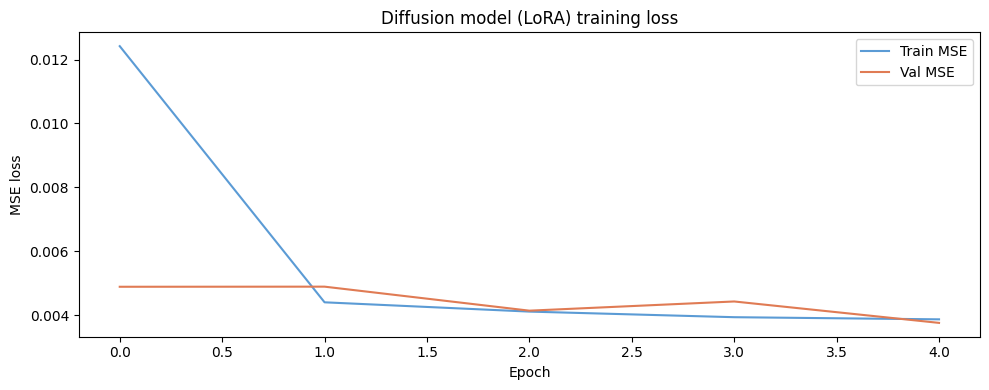

Loss log saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train MSE', color='#5b9bd5')
ax.plot(val_losses,   label='Val MSE',   color='#e07b54')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Diffusion model (LoRA) training loss')
ax.legend()
plt.tight_layout()
fig.savefig(LOG_DIR / 'figures' / 'lora_loss_curve.png', dpi=150)
plt.show()

with open(LOG_DIR / 'lora_training_log.json', 'w') as f:
    json.dump({'train_losses': train_losses, 'val_losses': val_losses}, f, indent=2)
print('Loss log saved.')


In [17]:
@torch.no_grad()
def ddim_encode(x0: torch.Tensor, mask: torch.Tensor,
                scheduler: DDIMScheduler, n_steps: int = 50,
                encode_timestep: int = 500) -> torch.Tensor:
    """
    DDIM forward encode: x0 -> x_L in the masked region.

    Parameters
    ----------
    x0              : (1,1,256,256)  input slice on DEVICE
    mask            : (1,1,256,256)  binary mask, 1=pathology region
    scheduler       : DDIMScheduler
    n_steps         : number of DDIM steps for encoding
    encode_timestep : target noise level L (0 to T-1)

    Returns
    -------
    x_L : (1,1,256,256)  noised image at timestep L
    """
    # Direct forward process: add noise to encode_timestep using scheduler
    noise = torch.randn_like(x0)
    t_tensor = torch.tensor([encode_timestep], device=x0.device).long()
    x_noised = scheduler.add_noise(x0, noise, t_tensor)

    # Apply only in masked region; keep original elsewhere
    x_L = x0 * (1 - mask) + x_noised * mask
    return x_L


@torch.no_grad()
def hybrid_decode(x_L: torch.Tensor, x0_orig: torch.Tensor,
                  mask: torch.Tensor,
                  unet: nn.Module,
                  ddpm_sched: DDPMScheduler,
                  ddim_sched: DDIMScheduler,
                  start_t: int = 500,
                  n_ddim_steps: int = 50) -> torch.Tensor:
    """
    Hybrid DDPM/DDIM reverse decode from t=start_t -> t=0.

    Inside  mask (M=1) : DDPM step  — stochastic, allows healthy regeneration
    Outside mask (M=0) : DDIM step  — deterministic, preserves healthy anatomy

    Returns
    -------
    x_hat : (1,1,256,256)  healthy reconstruction
    """
    unet.eval()
    ddim_sched.set_timesteps(n_ddim_steps)

    # Filter timesteps to those <= start_t
    timesteps = [t for t in ddim_sched.timesteps if t <= start_t]

    x = x_L.clone()

    for t_val in timesteps:
        t_batch = torch.tensor([t_val], device=x.device).long()

        noise_pred = unet(x, t_batch)

        ddpm_out = ddpm_sched.step(noise_pred, t_val, x)
        x_ddpm   = ddpm_out[0]
        ddim_out = ddim_sched.step(noise_pred, t_val, x)
        x_ddim   = ddim_out[0]

        # Blend: mask region uses DDPM, rest uses DDIM
        x = x_ddim * (1 - mask) + x_ddpm * mask

        # repaste clean original (noised to current t) outside mask
        t_tensor = torch.tensor([t_val], device=x.device).long()
        x_orig_t = ddpm_sched.add_noise(x0_orig, torch.randn_like(x0_orig), t_tensor)
        x        = x_orig_t * (1 - mask) + x * mask
    return x.clamp(0.0, 1.0)


def anomaly_map(x0: torch.Tensor, x_hat: torch.Tensor,
                smooth_sigma: float = 2.0) -> torch.Tensor:
    """
    Compute pixel-wise anomaly score |x0 - x_hat|.
    Optionally smooth with a Gaussian kernel (sigma in pixels).
    Returns a (1,1,256,256) float32 tensor on CPU.
    """
    diff = (x0 - x_hat).abs().cpu()
    if smooth_sigma > 0:
        # approximate Gaussian with a separable box filter
        k = max(3, int(smooth_sigma * 3) | 1)   # odd kernel size
        pad = k // 2
        kernel = torch.ones(1, 1, 1, k) / k
        diff = F.conv2d(F.conv2d(diff, kernel, padding=(0, pad)),
                        kernel.transpose(-1, -2), padding=(pad, 0))
    return diff

print('Inference functions defined.')


Inference functions defined.


14:26:21 | DEBUG | locator: <matplotlib.ticker.AutoLocator object at 0x7298ba76c350>


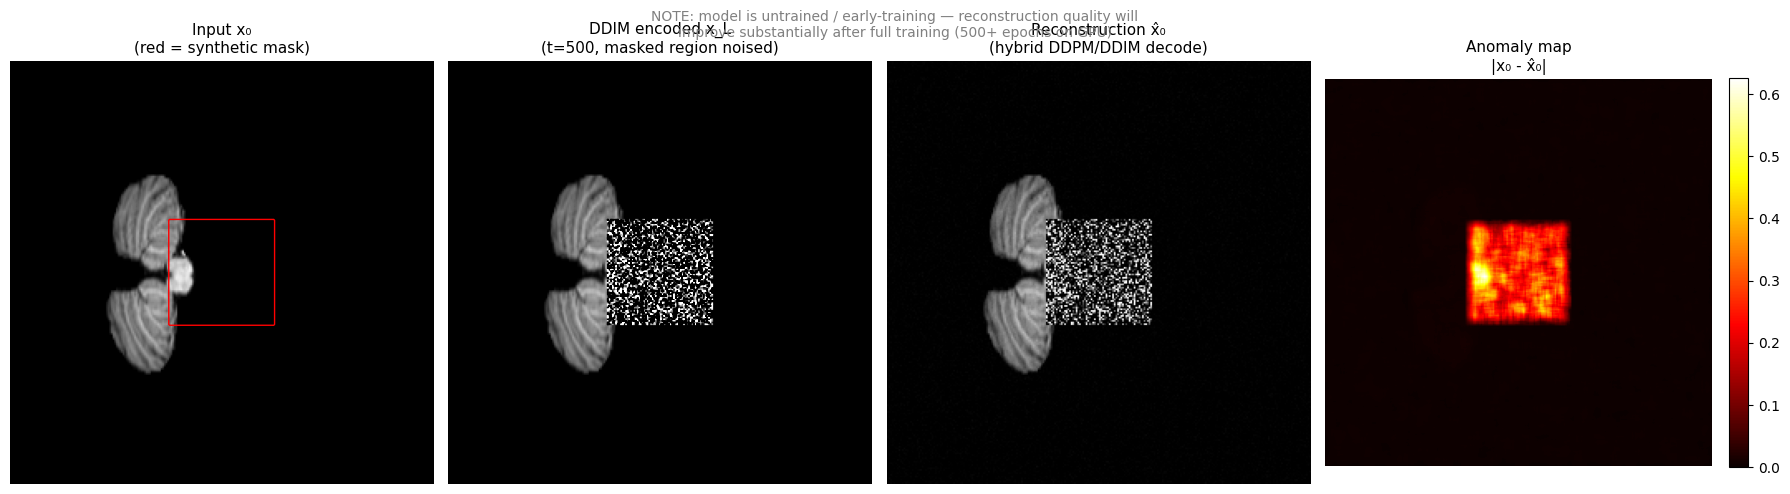

In [19]:
# ── pick one val slice ──────────────────────────────────────────────────
val_batch = next(iter(val_loader))
brain_fill = [b.mean().item() for b in val_batch]
best_idx = brain_fill.index(max(brain_fill))
x0_demo = val_batch[best_idx:best_idx+1].to(DEVICE)   # (1, 1, 256, 256)

# ── synthetic mask: 64x64 centre square ─────────────────────────────────
mask_demo = torch.zeros_like(x0_demo)
mask_demo[:, :, 96:160, 96:160] = 1.0   # centre 64x64

ENCODE_T  = 500   # how far to encode (noise level)
N_STEPS   = 50    # DDIM steps for decode

# ── run pipeline ────────────────────────────────────────────────────────
x_L    = ddim_encode(x0_demo, mask_demo, ddim_scheduler,
                     encode_timestep=ENCODE_T)

x_hat  = hybrid_decode(x_L, x0_demo, mask_demo,
                       unet, ddpm_scheduler, ddim_scheduler,
                       start_t=ENCODE_T, n_ddim_steps=N_STEPS)
a_map  = anomaly_map(x0_demo, x_hat, smooth_sigma=2.0)

# ── visualise ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(x0_demo[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].contour(mask_demo[0, 0].cpu().numpy(), levels=[0.5], colors='red', linewidths=1)
axes[0].set_title('Input x₀\n(red = synthetic mask)', fontsize=11)

axes[1].imshow(x_L[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'DDIM encoded x_L\n(t={ENCODE_T}, masked region noised)', fontsize=11)

axes[2].imshow(x_hat[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[2].set_title('Reconstruction x̂₀\n(hybrid DDPM/DDIM decode)', fontsize=11)

im = axes[3].imshow(a_map[0, 0].numpy(), cmap='hot', vmin=0)
axes[3].set_title('Anomaly map\n|x₀ - x̂₀|', fontsize=11)
fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis('off')

fig.suptitle(
    'NOTE: model is untrained / early-training — reconstruction quality will\n'
    'improve substantially after full training (500+ epochs on GPU)',
    fontsize=10, color='gray'
)
plt.tight_layout()
fig.savefig(LOG_DIR / 'figures' / 'demo_anomaly_pipeline.png', dpi=150)
plt.show()
